# Modeling Flight Departure Delays, a Monte-Carlo Case Study

**Question.** How late will a flight actually be, and what does that mean for a tight
connection? A single "average delay" number hides everything that matters, delays are
*not* symmetric and not bell-shaped. This notebook builds a **calibrated generative
model** of departure delay from real data, validates it, and turns it into a decision
tool that prices the risk of missing an onward flight.

**Data.** [`nycflights13`](https://github.com/tidyverse/nycflights13), **336,776 real
flights** departing the three New York airports (EWR, JFK, LGA) in 2013. We focus on
**Newark (EWR)** departures (n ≈ 117k).

**Approach.**
1. EDA, show the delay distribution is a **mixture**: on-time mass + heavy right tail.
2. **Model selection**, fit candidate distributions to the delayed tail; pick by AIC + KS.
3. **Validation**, hold-out goodness-of-fit; bootstrap confidence intervals; honest
   discussion of statistical vs. practical significance at large *n*.
4. **A driver of delay**, departure delay grows steadily through the day (a scheduling
   signal, not noise).
5. **Monte-Carlo model** → percentiles, threshold probabilities.
6. **Decision layer**, probability of missing a connection given a buffer and the
   airport's minimum connection time.

> The modeling code lives in `../src/model.py` so the notebook stays readable and the
> logic is unit-testable / reusable by the web app.

---

### 0 · Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from model import DelayModel, connection_miss_prob

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e6e6", "font.size": 10})
BLUE, SOFT, RED, INK = "#2a78d6", "#9ec5f4", "#d03b3b", "#0b0b0b"
np.random.seed(0)

### 1 · Load the real data

The dataset ships with the repo (gzipped). If you're running this fresh, it also loads
from the `nycflights13` PyPI source distribution or an R/CSV mirror, see `data/README`.

In [2]:
df = pd.read_csv("../data/nycflights13_flights.csv.gz")
ewr = df[(df.origin == "EWR") & df.dep_delay.notna()].copy()
x = ewr.dep_delay.values.astype(float)
print(f"{len(df):,} flights total · {len(ewr):,} Newark departures with a recorded delay")
ewr[["month","day","carrier","flight","dest","hour","dep_delay","arr_delay"]].head()

336,776 flights total · 117,596 Newark departures with a recorded delay


,month,day,carrier,flight,dest,hour,dep_delay,arr_delay
0,1,1,UA,1545,IAH,5,2.0,11.0
5,1,1,UA,1696,ORD,5,-4.0,12.0
6,1,1,B6,507,FLL,6,-5.0,19.0
13,1,1,UA,1124,SFO,6,-2.0,-14.0
16,1,1,UA,1187,LAS,6,-1.0,-8.0


### 2 · EDA, the shape that "average delay" hides

The mean departure delay is ~15 min, but the **median is −1** (most flights leave a touch
early). That gap is the signature of a **right-skewed mixture**: a big on-time cluster and
a long tail of serious delays.

  mean                15.11
  median              -1.00
  std                 41.32
  on-time (<=15m)      0.75
  >30m                 0.17
  >60m                 0.09
  max               1126.00


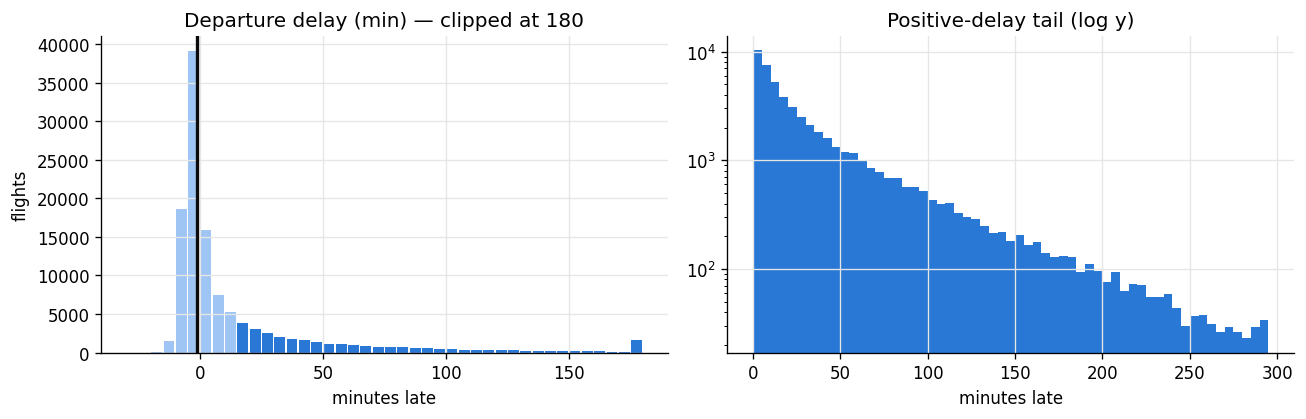

In [3]:
desc = {
    "mean": x.mean(), "median": np.median(x), "std": x.std(),
    "on-time (<=15m)": (x <= 15).mean(), ">30m": (x > 30).mean(),
    ">60m": (x > 60).mean(), "max": x.max(),
}
for k, v in desc.items():
    print(f"  {k:<16} {v:>8.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
edges = np.arange(-30, 185, 5)
cnt, _ = np.histogram(np.clip(x, -30, 180), bins=edges)
ctr = (edges[:-1] + edges[1:]) / 2
bar_colors = [SOFT if c < 15 else BLUE for c in ctr]
ax[0].bar(ctr, cnt, width=4.4, color=bar_colors)
ax[0].axvline(np.median(x), color=INK, lw=2); ax[0].set_title("Departure delay (min) — clipped at 180")
ax[0].set_xlabel("minutes late"); ax[0].set_ylabel("flights")
# log-scale tail
ax[1].hist(x[x > 0], bins=np.arange(0, 300, 5), color=BLUE)
ax[1].set_yscale("log"); ax[1].set_title("Positive-delay tail (log y)")
ax[1].set_xlabel("minutes late"); plt.tight_layout(); plt.show()

### 3 · Model selection, what distribution is the tail?

We model the **delayed component** (`dep_delay > 0`) and compare four standard
right-skewed families by **AIC** (fit quality penalized for parameters) and a
**Kolmogorov–Smirnov** statistic (distance between fitted and empirical CDF).

In [4]:
pos = x[x > 0]
cands = {"lognorm": stats.lognorm, "gamma": stats.gamma,
         "weibull_min": stats.weibull_min, "expon": stats.expon}
rows = []
sub = np.random.default_rng(0).choice(pos, 5000, replace=False)  # KS on a subsample
fits = {}
for name, dist in cands.items():
    par = dist.fit(pos, floc=0)
    fits[name] = par
    ll = np.sum(dist.logpdf(pos, *par))
    aic = 2 * len(par) - 2 * ll
    ks = stats.kstest(sub, lambda q, d=dist, p=par: d.cdf(q, *p)).statistic
    rows.append((name, aic, ks))
tbl = pd.DataFrame(rows, columns=["distribution", "AIC", "KS"]).sort_values("AIC")
tbl["ΔAIC"] = (tbl.AIC - tbl.AIC.min()).round(0)
display(tbl.set_index("distribution").round(4))
print("Winner:", tbl.iloc[0]['distribution'])

,AIC,KS,ΔAIC
distribution,,,
lognorm,484799.0240,0.0496,0.0
weibull_min,486050.0410,0.0596,1251.0
gamma,487434.6149,0.0609,2636.0
expon,491613.3241,0.1303,6814.0


Winner: lognorm


**Log-normal wins** on both criteria, consistent with the idea that delay is a
*multiplicative* pile-up of independent causes (traffic, crew, gate, weather), whose log
is roughly normal. Let's confirm with a **Q–Q plot**: points on the 45° line ⇒ good fit.

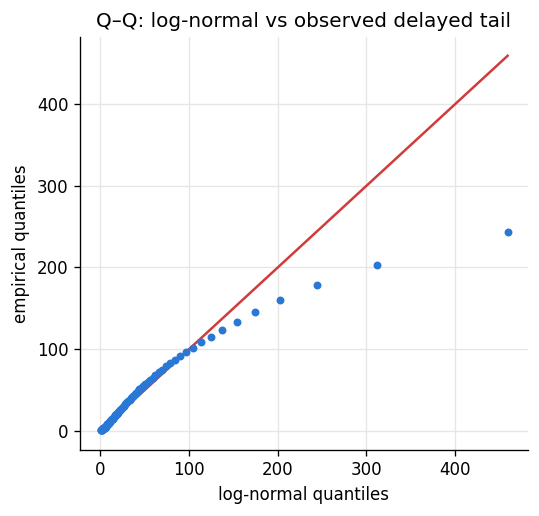

In [5]:
shape, loc, scale = fits["lognorm"]
q = np.linspace(0.01, 0.99, 99)
emp = np.quantile(pos, q)
theo = stats.lognorm.ppf(q, shape, loc, scale)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(theo, emp, s=14, color=BLUE, zorder=3)
lim = [0, max(theo.max(), emp.max())]
ax.plot(lim, lim, color=RED, lw=1.5)
ax.set_xlabel("log-normal quantiles"); ax.set_ylabel("empirical quantiles")
ax.set_title("Q–Q: log-normal vs observed delayed tail"); plt.tight_layout(); plt.show()

### 4 · Validation, does it generalize? (and a note on *n*)

Split the data in half, fit on train, test goodness-of-fit on the held-out half. Then
**bootstrap** a confidence interval for a percentile we care about.

In [6]:
rng = np.random.default_rng(1)
idx = rng.permutation(len(pos)); half = len(pos) // 2
tr, te = pos[idx[:half]], pos[idx[half:]]
par = stats.lognorm.fit(tr, floc=0)
ks = stats.kstest(rng.choice(te, 5000), lambda z: stats.lognorm.cdf(z, *par))
print(f"Hold-out KS: D={ks.statistic:.4f}  p={ks.pvalue:.3g}")

# bootstrap 95% CI for the 90th percentile of *all* departures
boot = [np.percentile(rng.choice(x, len(x)), 90) for _ in range(400)]
print(f"P90 delay = {np.percentile(x,90):.0f} min "
      f"(95% CI [{np.percentile(boot,2.5):.0f}, {np.percentile(boot,97.5):.0f}])")

Hold-out KS: D=0.0512  p=7.55e-12


P90 delay = 57 min (95% CI [56, 58])


> **Interpretation matters here.** With n≈50k the KS p-value is ~0, at that sample
> size *any* parametric model is formally "rejected" because tiny discrepancies become
> detectable. The honest read is the **effect size**: D≈0.05 means the fitted CDF is
> within ~5 percentage points of empirical everywhere, plenty good for risk estimation.
> Reporting the bootstrap CI keeps us honest about sampling uncertainty rather than
> leaning on a p-value that large-n makes meaningless.

### 5 · A real driver, delays compound through the day

Not all departure times are equal. Bucketing by **scheduled hour** shows delay climbing
monotonically from early morning to evening, knock-on effects propagate through the day
as aircraft and crews fall behind. This is the single most actionable feature for anyone
choosing a flight.

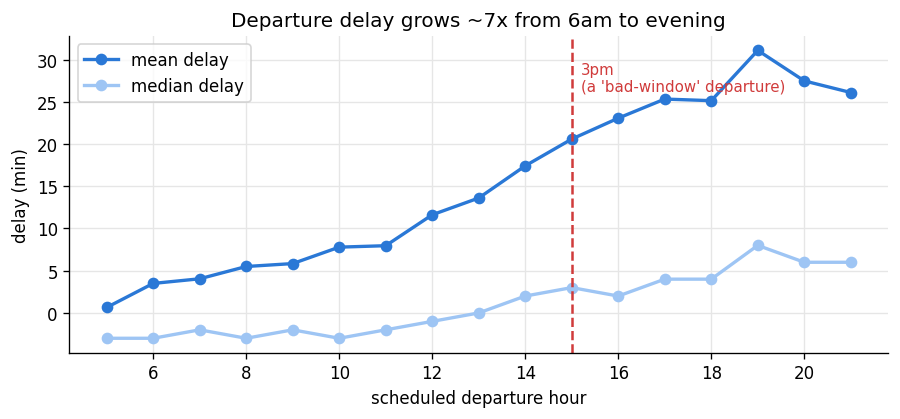

corr(hour, delay) = 0.219


,mean,median,count,p_late15
hour,,,,
5,0.65,-3.0,892,0.06
6,3.50,-3.0,10959,0.09
7,4.04,-2.0,8540,0.11
8,5.50,-3.0,9114,0.13
9,5.84,-2.0,5993,0.13
10,7.79,-3.0,6571,0.16
11,7.96,-2.0,4903,0.16
12,11.62,-1.0,6964,0.22
13,13.61,0.0,8886,0.24


In [7]:
g = ewr.groupby("hour").dep_delay.agg(["mean", "median", "count"])
g = g[g["count"] > 200]
g["p_late15"] = ewr.groupby("hour").dep_delay.apply(lambda s: (s > 15).mean())[g.index]

fig, ax = plt.subplots(figsize=(7.6, 3.6))
ax.plot(g.index, g["mean"], "-o", color=BLUE, lw=2, label="mean delay")
ax.plot(g.index, g["median"], "-o", color=SOFT, lw=2, label="median delay")
ax.axvline(15, color=RED, ls="--", lw=1.5)
ax.text(15.2, ax.get_ylim()[1]*0.8, "3pm\n(a 'bad-window' departure)", color=RED, fontsize=9)
ax.set_xlabel("scheduled departure hour"); ax.set_ylabel("delay (min)")
ax.set_title("Departure delay grows ~7x from 6am to evening"); ax.legend()
plt.tight_layout(); plt.show()
print("corr(hour, delay) =", round(np.corrcoef(ewr.hour, ewr.dep_delay)[0,1], 3))
display(g.round(2))

### 6 · The generative model → Monte-Carlo spread

`DelayModel.fit` learns the mixture directly from the data; sampling it gives the full
distribution, from which any percentile or threshold probability falls out. We fit two
models: **all-day EWR** and **the 3pm window only** (hours 14–16), to quantify how much
worse an afternoon departure is.


All-day EWR
  P5:-8  P10:-7  P25:-5  P50:-0  P75:14  P90:50  P95:94  P99:291
  P(>30m)=15%  P(>60m)=8%

3–4pm window
  P5:-7  P10:-6  P25:-3  P50:3  P75:21  P90:64  P95:115  P99:331


  P(>30m)=20%  P(>60m)=11%


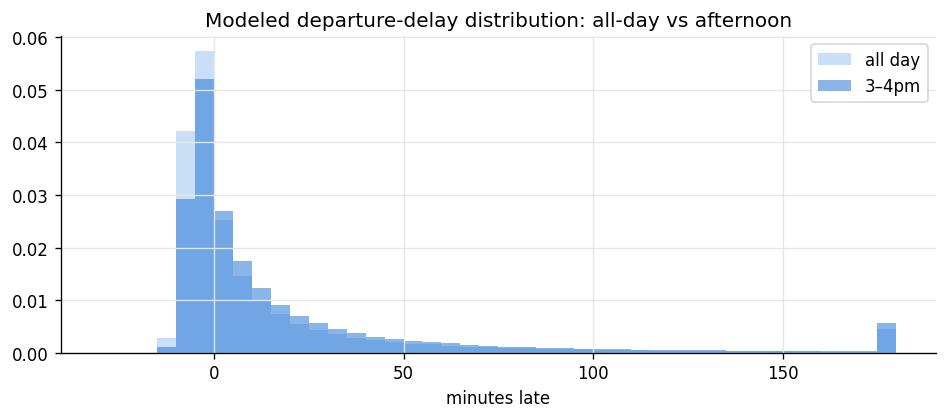

In [8]:
m_all = DelayModel.fit(x)
m_3pm = DelayModel.fit(ewr[ewr.hour.between(14, 16)].dep_delay.values.astype(float))

def report(m, label):
    p = m.percentiles()
    print(f"\n{label}")
    print("  " + "  ".join(f"P{k}:{v:.0f}" for k, v in p.items()))
    print(f"  P(>30m)={m.prob_exceeds(30):.0%}  P(>60m)={m.prob_exceeds(60):.0%}")
report(m_all, "All-day EWR"); report(m_3pm, "3–4pm window")

fig, ax = plt.subplots(figsize=(8, 3.6))
for m, c, lab in [(m_all, SOFT, "all day"), (m_3pm, BLUE, "3–4pm")]:
    s = np.clip(m.sample(200_000), -30, 180)
    ax.hist(s, bins=np.arange(-30, 185, 5), histtype="stepfilled",
            alpha=0.55, color=c, label=lab, density=True)
ax.set_title("Modeled departure-delay distribution: all-day vs afternoon")
ax.set_xlabel("minutes late"); ax.legend(); plt.tight_layout(); plt.show()

### 7 · Decision layer, will you make the connection?

Turning the distribution into the number a traveler actually wants. You miss an onward
flight when

$$\text{arrival delay} - \text{onward departure delay} \;>\; \text{buffer} - \text{MCT}$$

where MCT is the airport's minimum connection time. We price a **90-minute buffer** with a
**60-minute MCT**, first assuming the onward flight is punctual (conservative), then
letting it have its own (helpful) delay.

Buffer 90m, MCT 60m, 3pm inbound flight:
  P(miss)  conservative : 18%
  P(miss)  realistic    : 16%   ->  make it ~84% of the time


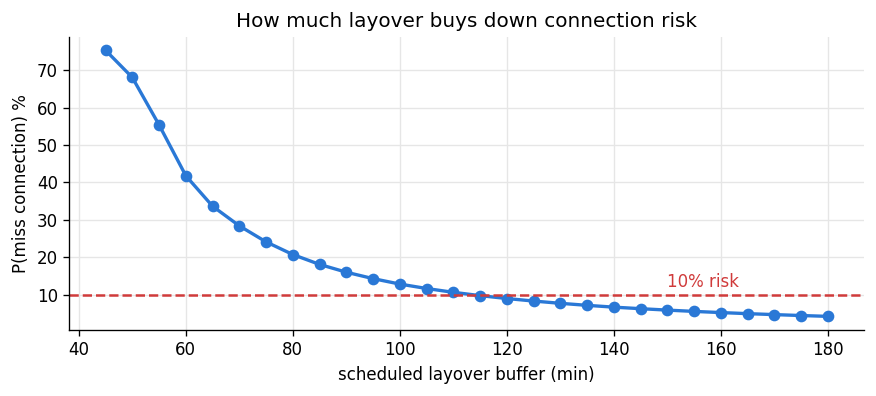

In [9]:
buffer, mct = 90, 60
p_cons = connection_miss_prob(m_3pm, buffer, mct)                       # onward punctual
p_real = connection_miss_prob(m_3pm, buffer, mct, onward=m_all)         # onward also delays
print(f"Buffer {buffer}m, MCT {mct}m, 3pm inbound flight:")
print(f"  P(miss)  conservative : {p_cons:.0%}")
print(f"  P(miss)  realistic    : {p_real:.0%}   ->  make it ~{1-p_real:.0%} of the time")

buffers = np.arange(45, 181, 5)
risk = [connection_miss_prob(m_3pm, b, mct, onward=m_all) for b in buffers]
fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(buffers, np.array(risk)*100, "-o", color=BLUE, lw=2)
ax.axhline(10, color=RED, ls="--", lw=1.5); ax.text(150, 12, "10% risk", color=RED)
ax.set_xlabel("scheduled layover buffer (min)"); ax.set_ylabel("P(miss connection) %")
ax.set_title("How much layover buys down connection risk"); plt.tight_layout(); plt.show()

### 8 · Takeaways

- Departure delay is a **log-normal mixture**, chosen by model selection and validated on
  held-out data, not assumed.
- **Time of day is the dominant controllable driver**: an afternoon departure carries
  several times the delay of an early-morning one. If a tight connection matters, fly early.
- The fitted model becomes a **decision tool**: it converts "the flight is often late" into
  a calibrated *probability of missing your connection* as a function of layover length.

**Honest limitations.** (1) `nycflights13` is 2013 NYC-origin data; magnitudes differ by
year, airport and airline, though the *shape* and *time-of-day* structure are stable and
well-replicated. (2) The mixture treats on-time and delayed components as independent of
weather/carrier; a fuller model would condition on them (a natural quantile-regression or
gradient-boosting extension). (3) Connection math uses a static MCT and ignores
correlation between the inbound delay and the onward flight's delay (bad-weather days hit
both). Each is a clearly scoped next step rather than a hidden assumption.

*Reusable model code: `../src/model.py`. Interactive version: `../app/index.html`.*